#RANDOM FOREST VS XGBOOST

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [0]:

df = pd.read_parquet("/Volumes/workspace/default/gst-fraud&anomaly_detection/Silver/silver_purchase_orders")

In [0]:
df.shape
df.head()
print(df.columns.tolist())

['po_id', 'director_pan_1', 'vendor_id', 'year_month', 'hsn_code', 'po_date', 'buyer_gstin', 'buyer_state', 'product_desc', 'quantity', 'unit', 'base_amount', 'cgst_rate', 'sgst_rate', 'igst_rate', 'cgst_amt', 'sgst_amt', 'igst_amt', 'cess_amt', 'total_amount', 'ewb_number', 'ewb_generated_date', 'place_of_supply', 'delivery_state', 'invoice_billing_name', 'po_vendor_name', 'id_26', 'status', 'ingestion_timestamp_28', 'year', 'month', 'gstin', 'trade_name', 'legal_name', 'billing_state', 'registration_date', 'vendor_status', 'composition_flag', 'filing_history_q1', 'filing_history_q2', 'filing_history_q3', 'filing_history_q4', 'filing_history_q5', 'filing_history_q6', 'director_pan_2', 'vendor_row_id', 'ingestion_timestamp_46', 'invoice_date', 'invoice_number', 'gstr2b_itc_available', 'itc_claimed_by_buyer', 'id_51', 'is_gstin_valid', 'gst_state_code', 'gst_state_name', 'state_mismatch', 'blacklist_gstin', 'blacklisted', 'gst_rate', 'actual_gst_rate', 'rate_mismatch', 'total_po_value',

In [0]:
features = [
    "name_sim_score",
    "spike_ratio",
    "vendor_age_days",
    "filing_compliance_rate",
    "is_march_invoice",
    "invoice_count_same_vendor_same_day",
    "hsn_rate_delta",
    "director_overlap_flag",
    "blacklisted",
    "rate_mismatch",
    "value_spike",
    "duplicate_invoice",
    "vendor_non_filer",
    "missing_ewb",
    "high_value_invoice_flag",
    "vendor_po_frequency",
    "invoice_to_avg_ratio",
    "rule_fail_count"
]

In [0]:
X = df[features]

y = df["is_anomalous"]

po_ids = df["po_id"]

X.isnull().sum()

name_sim_score                            0
spike_ratio                           23255
vendor_age_days                           0
filing_compliance_rate                    0
is_march_invoice                          0
invoice_count_same_vendor_same_day        0
hsn_rate_delta                            0
director_overlap_flag                     0
blacklisted                               0
rate_mismatch                             0
value_spike                               0
duplicate_invoice                         0
vendor_non_filer                          0
missing_ewb                               0
high_value_invoice_flag                   0
vendor_po_frequency                       0
invoice_to_avg_ratio                      0
rule_fail_count                           0
dtype: int64

In [0]:
print(X.shape)
print(y.shape)
print(po_ids.shape)
print(y.value_counts())

(50480, 18)
(50480,)
(50480,)
is_anomalous
0    47407
1     3073
Name: count, dtype: int64


##Train - test Split

In [0]:
X_train, X_test, y_train, y_test, po_train, po_test = train_test_split(
    X,
    y,
    po_ids,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [0]:
print(X_train.shape)
print(X_test.shape)

(40384, 18)
(10096, 18)


##Random Forest

In [0]:
from sklearn.ensemble import RandomForestClassifier


rf = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=500, n_jobs=-1,
                       random_state=42)

In [0]:
rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

In [0]:
#Metrics

rf_acc = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(y_test, rf_pred)

rf_recall = recall_score(y_test, rf_pred)

rf_f1 = f1_score(y_test, rf_pred)

rf_auc = roc_auc_score(y_test, rf_prob)

print("Accuracy :", rf_acc)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC AUC  :", rf_auc)

Accuracy : 0.97236529318542
Precision: 0.9590163934426229
Recall   : 0.5707317073170731
F1 Score : 0.7155963302752294
ROC AUC  : 0.9891198743228862


In [0]:
#Classification report
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      9481
           1       0.96      0.57      0.72       615

    accuracy                           0.97     10096
   macro avg       0.97      0.78      0.85     10096
weighted avg       0.97      0.97      0.97     10096



In [0]:
#Confusion Matrix

rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

[[9466   15]
 [ 264  351]]


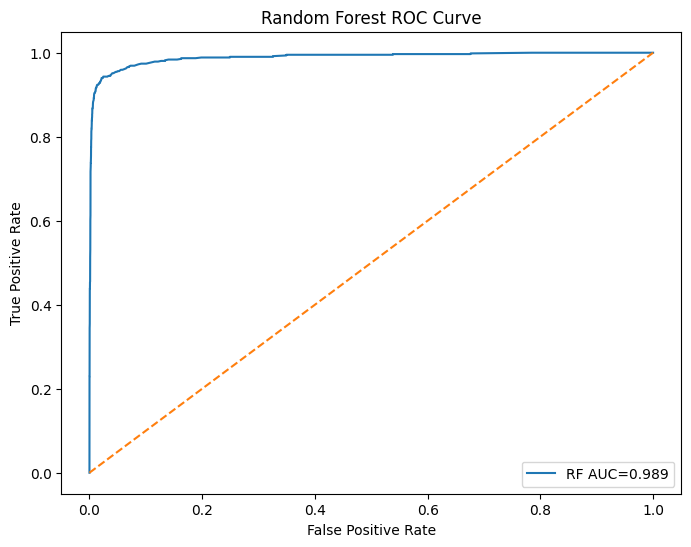

In [0]:
#ROC - CURVE


rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"RF AUC={rf_auc:.3f}"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")

plt.legend()

plt.show()

In [0]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)


# importance_df.plot.bar(
#     x="Feature",
#     y="Importance",
#     title="Feature Importance",
#     figsize=(12,8)
# )

                               Feature  Importance
2                      vendor_age_days    0.306840
15                 vendor_po_frequency    0.295727
0                       name_sim_score    0.096343
3               filing_compliance_rate    0.077553
1                          spike_ratio    0.062412
16                invoice_to_avg_ratio    0.059130
17                     rule_fail_count    0.025800
8                          blacklisted    0.014068
5   invoice_count_same_vendor_same_day    0.012996
12                    vendor_non_filer    0.010388
4                     is_march_invoice    0.008774
13                         missing_ewb    0.007780
6                       hsn_rate_delta    0.007293
14             high_value_invoice_flag    0.005885
9                        rate_mismatch    0.003496
10                         value_spike    0.002765
11                   duplicate_invoice    0.002751
7                director_overlap_flag    0.000000


In [0]:
#SAVE Preditons
rf_pred_df = pd.DataFrame({
    "po_id": po_test.values,
    "actual": y_test.values,
    "rf_prediction": rf_pred,
    "rf_probability": rf_prob
})

rf_pred_df.head()

,po_id,actual,rf_prediction,rf_probability
0,PO0024147,0,0,0.114
1,PO0017479,0,0,0.050
2,PO0034938,0,0,0.026
3,PO0000027,1,1,0.778
4,PO0028867,0,0,0.026


In [0]:
import joblib

model_path = "/Volumes/workspace/default/gst-fraud&anomaly_detection/ML MODELS/random_forest_model.pkl"
joblib.dump(rf, model_path)

import os

print(os.path.exists(model_path))

True


##XG BOOST

In [0]:
%pip install xgboost

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False
)

xgb.fit(X_train, y_train)

/local_disk0/.ephemeral_nfs/envs/pythonEnv-f2c16326-d2f9-4301-bb25-f1002721d71f/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [14:17:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [0]:
#Predictions

xgb_prob = xgb.predict_proba(X_test)[:,1]
threshold = 0.35

xgb_pred = (xgb_prob >= threshold).astype(int)

In [0]:
#Metrics

xgb_acc = accuracy_score(y_test, xgb_pred)

xgb_precision = precision_score(y_test, xgb_pred)

xgb_recall = recall_score(y_test, xgb_pred)

xgb_f1 = f1_score(y_test, xgb_pred)

xgb_auc = roc_auc_score(y_test, xgb_prob)

print("Accuracy :", xgb_acc)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)
print("ROC AUC  :", xgb_auc)

Accuracy : 0.973553882725832
Precision: 0.9860335195530726
Recall   : 0.5739837398373984
F1 Score : 0.7255909558067831
ROC AUC  : 0.9868739618732544


In [0]:
#Classification


print(classification_report(
    y_test,xgb_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      9481
           1       0.99      0.57      0.73       615

    accuracy                           0.97     10096
   macro avg       0.98      0.79      0.86     10096
weighted avg       0.97      0.97      0.97     10096



In [0]:
#Confusion Matrix

xgb_cm = confusion_matrix(
    y_test,
    xgb_pred
)

print(xgb_cm)

[[9476    5]
 [ 262  353]]


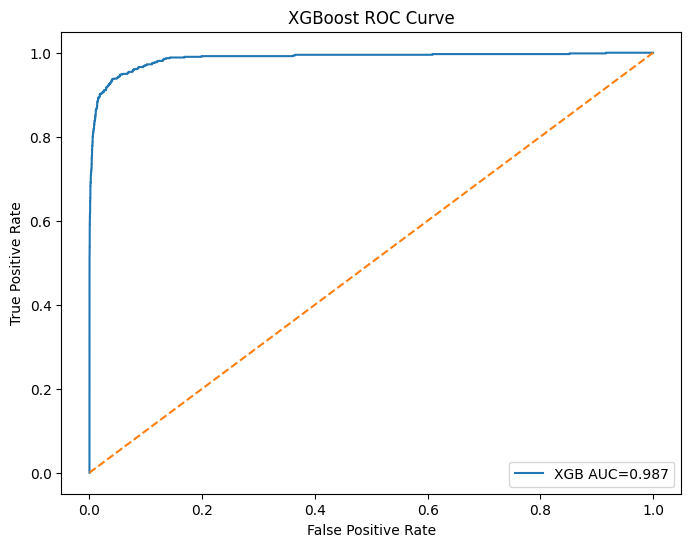

In [0]:
#ROC Curve

xgb_fpr, xgb_tpr, _ = roc_curve(
    y_test,
    xgb_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f"XGB AUC={xgb_auc:.3f}"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")

plt.legend()

plt.show()

In [0]:
#Feature importance

xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

print(xgb_importance)

                               Feature  Importance
2                      vendor_age_days    0.158989
15                 vendor_po_frequency    0.156030
3               filing_compliance_rate    0.147778
12                    vendor_non_filer    0.118761
17                     rule_fail_count    0.079375
8                          blacklisted    0.055312
13                         missing_ewb    0.051685
6                       hsn_rate_delta    0.042658
16                invoice_to_avg_ratio    0.029656
1                          spike_ratio    0.028802
9                        rate_mismatch    0.027036
11                   duplicate_invoice    0.024167
0                       name_sim_score    0.020857
5   invoice_count_same_vendor_same_day    0.018342
10                         value_spike    0.015150
4                     is_march_invoice    0.013853
14             high_value_invoice_flag    0.011550
7                director_overlap_flag    0.000000


In [0]:
#Save Prediction

xgb_pred_df = pd.DataFrame({
    "po_id": po_test.values,
    "actual": y_test.values,
    "xgb_prediction": xgb_pred,
    "xgb_probability": xgb_prob
})

In [0]:
import joblib

model_path = "/Volumes/workspace/default/gst-fraud&anomaly_detection/ML MODELS/xgboost_model.pkl"
joblib.dump(xgb, model_path)


import os

print(os.path.exists(model_path))

True


##Comparsion table



In [0]:
comparison = pd.DataFrame({
    "Model":["Random Forest","XGBoost"],
    "Accuracy":[rf_acc,xgb_acc],
    "Precision":[rf_precision,xgb_precision],
    "Recall":[rf_recall,xgb_recall],
    "F1":[rf_f1,xgb_f1],
    "ROC_AUC":[rf_auc,xgb_auc]
})

comparison_path = "/Volumes/workspace/default/gst-fraud&anomaly_detection/ML MODELS/comparison_table.csv"
comparison.to_csv(comparison_path, index=False)

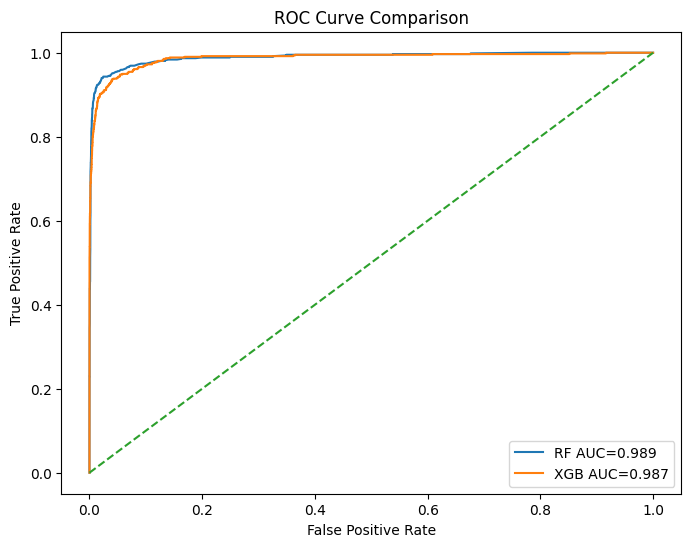

,actual,predicted,prob
42235,0,0,0.047524
3112,0,0,0.043786
2683,0,0,0.115947
305,1,1,0.427761
15231,0,0,0.033909


In [0]:
#ROC Overlay

plt.figure(figsize=(8,6))

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"RF AUC={rf_auc:.3f}"
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f"XGB AUC={xgb_auc:.3f}"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

results_df = pd.DataFrame({
    "actual":y_test,
    "predicted":xgb_pred,
    "prob":xgb_prob
})

results_df.head(5)  

In [0]:
#False Postive Analyis

fp = results_df[
    (results_df["actual"]==0) &
    (results_df["predicted"]==1)
]

fp.head(5)

,actual,predicted,prob
28243,0,1,0.371255
28216,0,1,0.377182
28239,0,1,0.378501
28209,0,1,0.360928
43560,0,1,0.904810


In [0]:
#False negative Analysis


fn = results_df[
    (results_df["actual"]==1) &
    (results_df["predicted"]==0)
]

fn.head(5)


,actual,predicted,prob
12182,1,0,0.333549
25071,1,0,0.178179
12321,1,0,0.316923
6292,1,0,0.346548
43740,1,0,0.294623


##Power Bi

In [0]:
#Metrics

spark_df = spark.createDataFrame(comparison)
spark_df.write \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable("comparison_table")

In [0]:
#ROC


import pandas as pd

roc_rf = pd.DataFrame({
    "FPR": rf_fpr,
    "TPR": rf_tpr,
    "Model": "Random Forest"
})

roc_xgb = pd.DataFrame({
    "FPR": xgb_fpr,
    "TPR": xgb_tpr,
    "Model": "XGBoost"
})

baseline = pd.DataFrame({
    "FPR": [0, 1],
    "TPR": [0, 1],
    "Model": "Random Baseline"
})

roc_powerbi = pd.concat(
    [roc_rf, roc_xgb, baseline],
    ignore_index=True
)

display(roc_powerbi)

FPR,TPR,Model
0.0,0.0,Random Forest
0.0,0.004878048780487805,Random Forest
0.0,0.00975609756097561,Random Forest
0.0,0.016260162601626018,Random Forest
0.0,0.024390243902439025,Random Forest
0.0,0.027642276422764227,Random Forest
0.0,0.032520325203252036,Random Forest
0.0,0.03414634146341464,Random Forest
0.0,0.04065040650406504,Random Forest
0.0,0.04227642276422764,Random Forest


In [0]:
spark.createDataFrame(roc_powerbi) \
    .write \
    .mode("overwrite") \
    .saveAsTable("roc_curve_comparison")

In [0]:
#Random Forest Predition Tabel with Poid

rf_predictions = spark.createDataFrame(
    rf_pred_df
)

rf_predictions = (
    rf_predictions
    .dropDuplicates(["po_id"])
)


rf_predictions.write \
    .mode("overwrite") \
    .saveAsTable(
        "rf_predictions"
    )

In [0]:
#XGBoost Predition Tabel with Poid

xgb_predictions = spark.createDataFrame(
    xgb_pred_df
)


xgb_predictions = (
    xgb_predictions
    .dropDuplicates(["po_id"])
)



xgb_predictions.write \
    .mode("overwrite") \
    .saveAsTable(
        "xgb_predictions"
    )

In [0]:
##Feature importance table

# Random Forest Importance
rf_importance = pd.DataFrame({
    "model_name": "Random Forest",
    "feature_name": X.columns,
    "importance_score": rf.feature_importances_
})

# XGBoost Importance
xgb_importance = pd.DataFrame({
    "model_name": "XGBoost",
    "feature_name": X.columns,
    "importance_score": xgb.feature_importances_
})

# Combine
feature_importance = pd.concat(
    [rf_importance, xgb_importance],
    ignore_index=True
)

# Sort within model
feature_importance = feature_importance.sort_values(
    ["model_name", "importance_score"],
    ascending=[True, False]
)

display(feature_importance)

model_name,feature_name,importance_score
Random Forest,vendor_age_days,0.3068399448026308
Random Forest,vendor_po_frequency,0.2957265154806733
Random Forest,name_sim_score,0.09634305377672152
Random Forest,filing_compliance_rate,0.07755265058557519
Random Forest,spike_ratio,0.062411926890386646
Random Forest,invoice_to_avg_ratio,0.05912956493676843
Random Forest,rule_fail_count,0.02579985953810297
Random Forest,blacklisted,0.014067949191834078
Random Forest,invoice_count_same_vendor_same_day,0.012996038701058452
Random Forest,vendor_non_filer,0.010387826803994832


In [0]:
spark.createDataFrame(feature_importance) \
    .write \
    .mode("overwrite") \
    .saveAsTable("feature_importance")

spark.createDataFrame(feature_importance) \
    .write \
    .mode("overwrite") \
    .parquet("/Volumes/workspace/default/gst-fraud&anomaly_detection/ML MODELS/feature_importance.parquet")